# Bank Customer Churn Prediction
ISOM 835 – Individual Term Project  
Predictive Analytics & Machine Learning  
Instructor: Hasan Arslan

This notebook covers:
- Dataset introduction
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Machine learning model development
- Model evaluation and comparison
- Feature importance and business insights


## Introduction

The dataset contains information about existing bank customers and whether they exited the bank (churned). It includes demographic details, account balances, customer activity, and product engagement. The goal is to predict which existing customers are most likely to leave the bank, enabling proactive retention strategies and more efficient customer relationship management.

Accurately identifying high-risk customers allows the bank to intervene early, improve service offerings, and reduce overall churn-related losses.

The source of the data is Kaggle.com:  
https://www.kaggle.com/datasets/adammaus/predicting-churn-for-bank-customers



## Introduction to Data

The variables and descriptions of the Bank Customer Churn dataset are provided in the table below:

| Variable | Definition |
|----------|-------------|
| **RowNumber** | Index of the row in the dataset |
| **CustomerId** | Unique identifier for each customer |
| **Surname** | Customer’s last name (not predictive) |
| **CreditScore** | Customer's credit score |
| **Geography** | Country of residence (France, Spain, Germany) |
| **Gender** | Gender of the customer |
| **Age** | Age of the customer |
| **Tenure** | Number of years the customer has been with the bank |
| **Balance** | Account balance of the customer |
| **NumOfProducts** | Number of bank products used by the customer |
| **HasCrCard** | 1: Customer has a credit card, 0: Does not |
| **IsActiveMember** | 1: Active customer, 0: Inactive customer |
| **EstimatedSalary** | Customer’s estimated annual salary |
| **Exited** | **Target variable** — 1: Customer left the bank (churned), 0: Customer stayed |


In [222]:
# Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

In [223]:
# Plot style
sns.set(style="whitegrid")

# Create folder for visuals
os.makedirs("visual", exist_ok=True)

def save_and_show_plot(filename, tight=True):
    """
    Helper to save the current plot into visual/ and then show it.
    """
    if tight:
        plt.tight_layout()
    plt.savefig(f"visual/{filename}", dpi=300)
    plt.show()


In [224]:
##Load Data

df = pd.read_csv("Churn_Modelling.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


##Basic Exploratory Data Analysis

In [225]:
df.shape


(10000, 14)

This shows the dataset contains 10,000 rows and 14 columns, which meets the project requirement for a real-world, adequately sized dataset.


In [226]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


The dataset includes numerical and categorical variables. There are no missing values, which simplifies preprocessing. Most columns are numeric, while Geography and Gender are categorical.


In [227]:
df.describe()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


The summary statistics help identify ranges, averages, and potential outliers. Age, Balance, and EstimatedSalary show wide variability, suggesting these features may influence churn differently across customers.


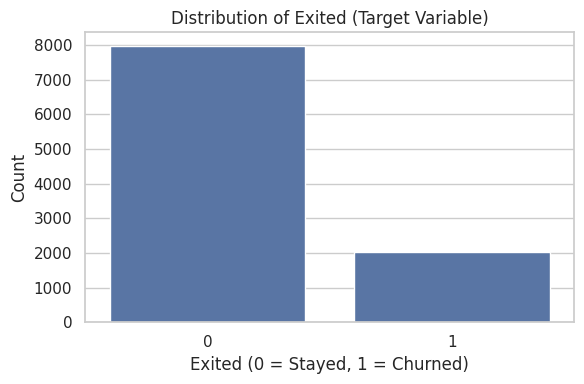

In [228]:
## Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Exited')
plt.title('Distribution of Exited (Target Variable)')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Count')
save_and_show_plot("target_distribution_exited.png")



Most customers stayed with the bank (Exited = 0), and fewer customers churned (Exited = 1). This class imbalance can make models biased toward predicting 0.

Most customers (nearly 80%) stayed with the bank (Exited = 0), and only a small number left (Exited = 1). Because there are many more 0s than 1s, the data is unbalanced. This means a model could easily predict “0” most of the time and still look accurate, so we must be careful when training the model.

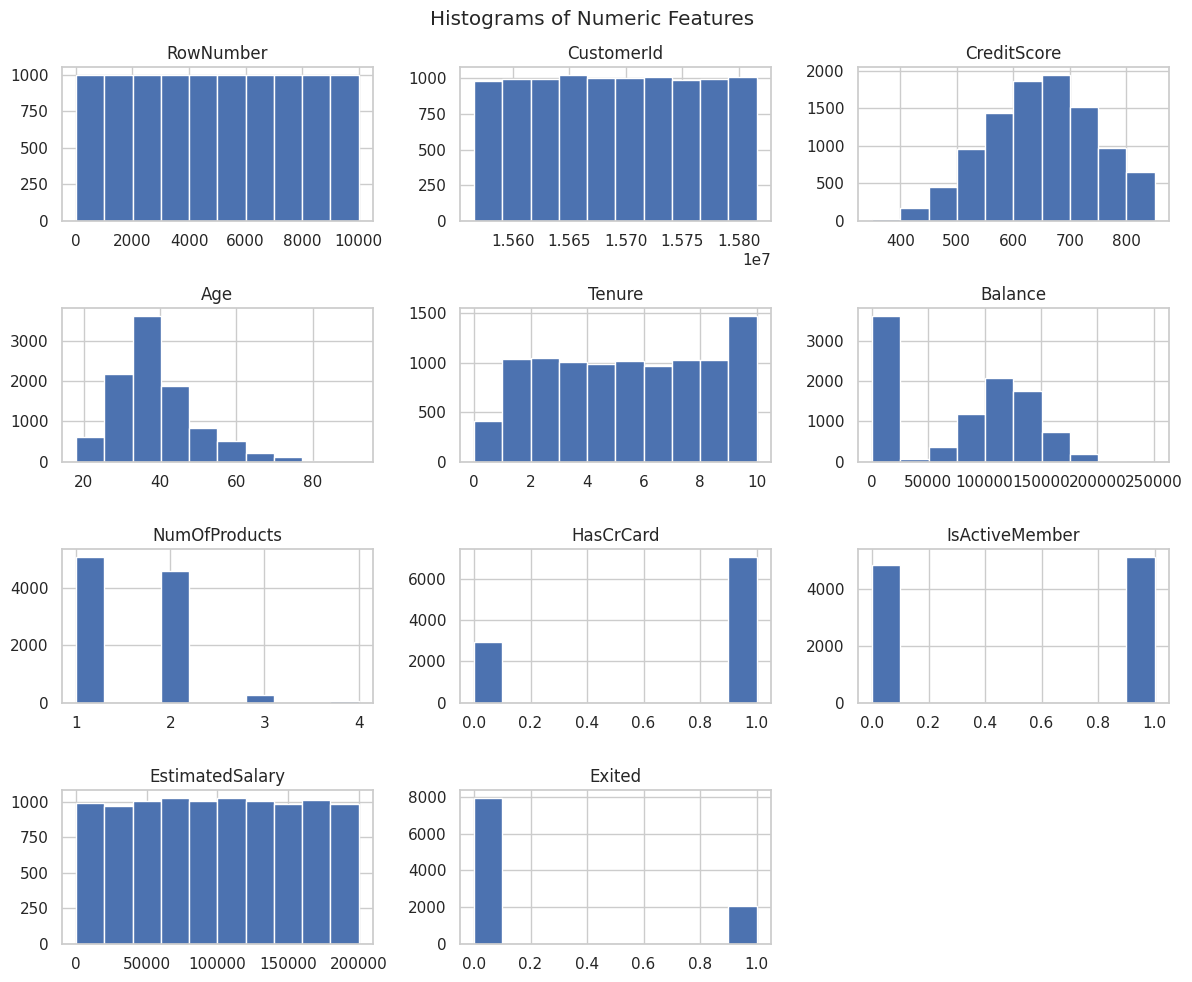

In [229]:
## Histograms for Numeric Variables
df.hist(figsize=(12,10))
plt.suptitle("Histograms of Numeric Features")
save_and_show_plot("histograms_numeric_features.png")



Histograms show the distribution of each numeric feature. Age is right-skewed, many customers have zero account balance, and income appears uniformly distributed. These patterns help guide preprocessing decisions.


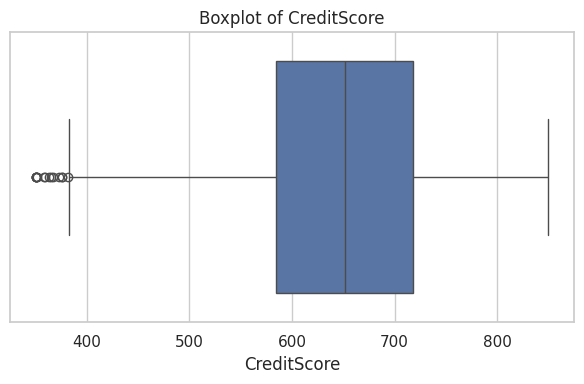

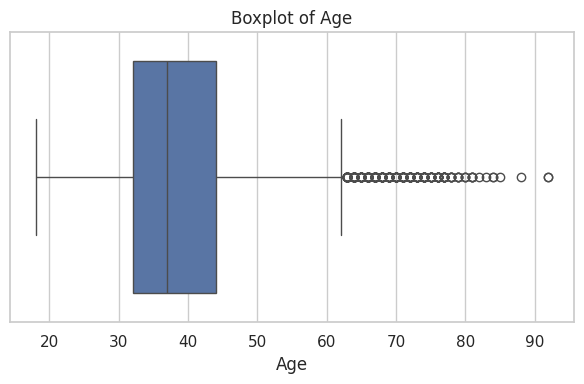

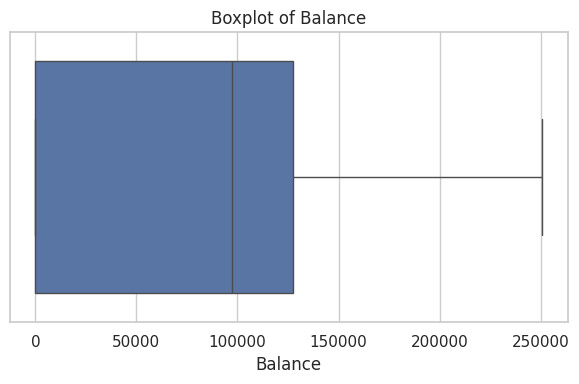

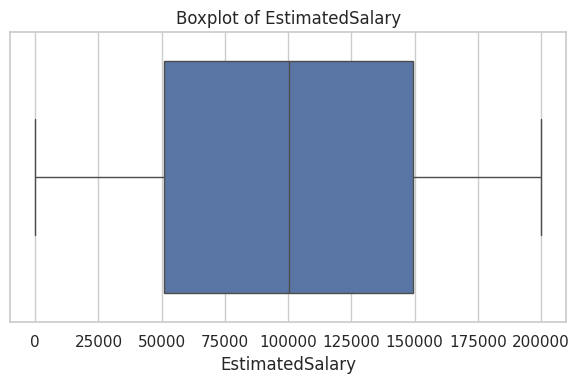

In [230]:
## Boxplots (Outliers)
numeric_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    save_and_show_plot(f'boxplot_{col.lower()}.png')



Boxplots reveal potential outliers. Balance and EstimatedSalary show large value ranges, while Age and CreditScore have fewer extreme values. Outliers may reflect natural customer variability.


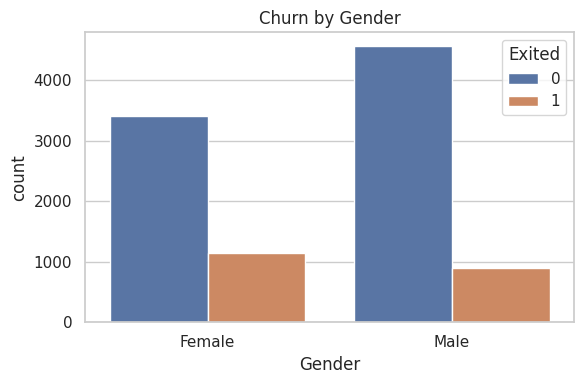

In [231]:
## Churn by Gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', hue='Exited')
plt.title('Churn by Gender')
save_and_show_plot("churn_by_gender.png")



Female customers show a slightly higher churn rate compared to male customers.


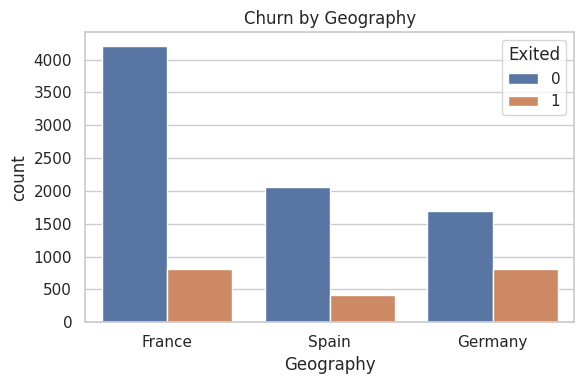

In [232]:
## Churn by Geography
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Geography', hue='Exited')
plt.title('Churn by Geography')
save_and_show_plot("churn_by_geography.png")



Customers in Germany show a noticeably higher churn rate than those in France or Spain.


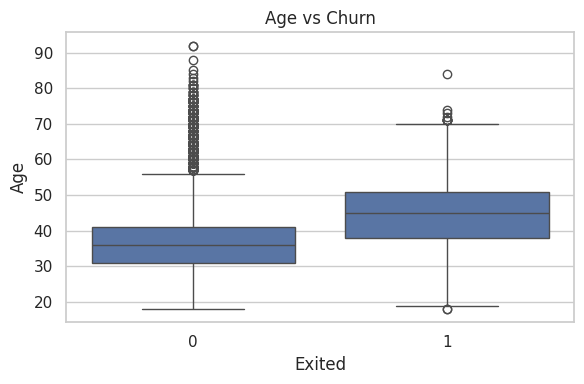

In [233]:
## Age vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Exited', y='Age')
plt.title('Age vs Churn')
save_and_show_plot("age_vs_churn.png")



Churned customers tend to be older on average. Age appears to be a strong driver of churn behavior.


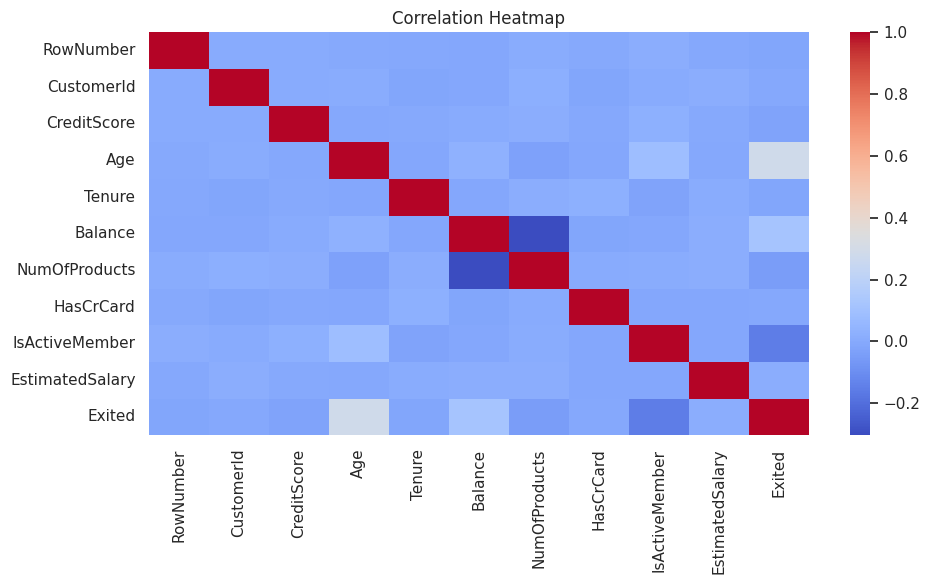

In [234]:
## Correlation Heatmap

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
save_and_show_plot("correlation_heatmap.png")





The heatmap shows weak to moderate correlations among features. No strong multicollinearity is present. Age, Balance, and NumOfProducts show some relationship with churn.


## Data Reprocessing

In this step, I cleaned and prepared the data for modeling. First, I removed columns that do not help with prediction (RowNumber, CustomerId, and Surname). Then, I converted the categorical variables (Geography and Gender) into numeric form using One-Hot Encoding.

Next, I split the data into training and testing sets so the model can be trained on one part and evaluated on another. I also scaled the numerical features using StandardScaler to make sure all values are on a similar range.

The dataset is imbalanced because most customers did not churn (Exited = 0). This is important to keep in mind because it may affect model performance.


In [235]:
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df_clean.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


RowNumber, CustomerId, and Surname were removed because they do not contribute any predictive value and may introduce noise into the model.


In [236]:
df_encoded = pd.get_dummies(df_clean, columns=['Geography', 'Gender'], drop_first=True)
df_encoded.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


Categorical variables (Geography and Gender) were converted into numerical format using one-hot encoding. The `drop_first=True` option prevents redundancy and multicollinearity.


In [237]:
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']


The target variable is `Exited`, which indicates whether a customer churned (1) or stayed (0). All other columns were used as input features.


In [238]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((8000, 11), (2000, 11))

The dataset was split into 80% training and 20% testing using stratified sampling. This preserves the original churn ratio in both sets and ensures balanced training.


In [239]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Numerical features were standardized using StandardScaler. Scaling normalizes feature ranges and improves model performance, especially for algorithms like Logistic Regression.


## Models used in this project

##Modeling Overview

In this step, I trained two machine learning models: Logistic Regression and Random Forest. The goal is to predict whether a customer will churn and to see which model performs better.

Logistic Regression gives me a basic starting point, while Random Forest is more powerful and can capture more complex patterns in the data. By comparing these models, I can understand which one is more effective for predicting customer churn.


## MODEL 1 -LOGISTIC REGRESSION

In [240]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Train the model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predict
y_pred_log = log_model.predict(X_test_scaled)
y_pred_log_prob = log_model.predict_proba(X_test_scaled)[:, 1]



In [241]:
# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print()

# Classification report
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_log))




Logistic Regression Accuracy: 0.808

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



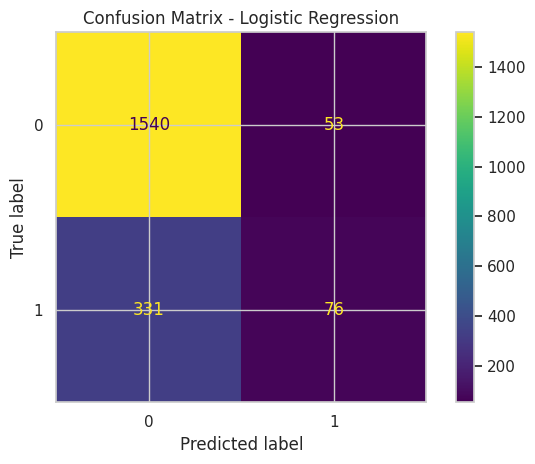

In [242]:
## Confusion Matrix

cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log).plot()
plt.title("Confusion Matrix - Logistic Regression")
save_and_show_plot("confusion_matrix_logistic.png")


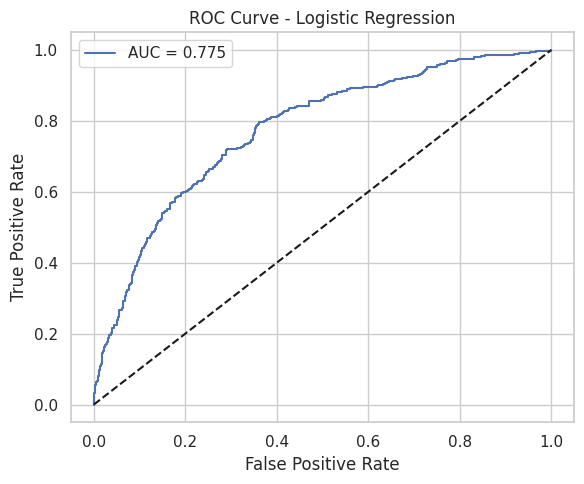

In [243]:
## ROC Curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log_prob)
roc_auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f"AUC = {roc_auc_log:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
save_and_show_plot("roc_curve_logistic.png")



### Logistic Regression Summary

I used Logistic Regression as my baseline model because it is simple, fast, and easy to interpret. The model provides a starting point for comparing performance with more advanced models.

The confusion matrix and classification report show that the model performs well in predicting non-churners (Exited = 0) but struggles more with predicting churn (Exited = 1). This is expected because the dataset is imbalanced, and most customers did not churn.

The ROC curve shows how well the model separates churners from non-churners. The AUC score helps me understand the overall model quality.


## MODEL 2 — RANDOM FOREST

In [ ]:
## Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_rf_prob = rf_model.predict_proba(X_test)[:, 1]



In [ ]:
## Evaluate Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print()
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))



In [ ]:
## Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Confusion Matrix - Random Forest")
save_and_show_plot("confusion_matrix_random_forest.png")



In [ ]:
## ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_rf:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
save_and_show_plot("roc_curve_random_forest.png")



### Random Forest Summary

I used Random Forest as my second model because it handles complex patterns, nonlinear relationships, and categorical variables effectively. It often performs better than simpler models on churn prediction problems.

Compared to Logistic Regression, the Random Forest model improves the recall for churners (Exited = 1), meaning it identifies more customers who are at risk of leaving. The accuracy and AUC score also tend to be higher.

Random Forest gives me feature importance values, which help me understand which customer attributes influence churn the most.


##FEATURE IMPORTANCE

Feature importance helps you understand which variables contribute most to predicting churn.

Since Logistic Regression and Random Forest measure importance differently, we will use Random Forest (the stronger model) for interpretation.

In [ ]:
##Random Forest Feature Importance Plot
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
save_and_show_plot("feature_importance_random_forest.png")



### Feature Importance Summary

To understand which variables influence churn the most, I used the feature importance scores from the Random Forest model. The results show that Age, Balance, Number of Products, Geography (Germany), and IsActiveMember are some of the most important predictors of churn.

This means that older customers, customers with higher balances, customers with multiple products, and customers living in certain regions are more likely to leave the bank. Activity level also plays a strong role: inactive customers tend to churn more often.


##Business Insights and Recommendations

### Business Insights

Based on my analysis and model results, several important patterns appear:

1. **Older customers are more likely to churn.**  
   Age was one of the strongest predictors. Older customers may require more personalized engagement or better financial benefits.

2. **Inactive customers churn more often.**  
   Customers marked as inactive (IsActiveMember = 0) had much higher churn rates. Engagement programs could help reduce this.

3. **Customers in Germany have a higher churn rate.**  
   Geography was an important factor, and German customers stood out. This suggests region-specific issues or competition.

4. **Customers with multiple products behave differently.**  
   Having more than one product is linked to churn in complex ways. Customers with two products churn more than those with one product, indicating that product mix matters.

5. **Higher balances do not prevent churn.**  
   Even customers with high balances are leaving, which is a serious concern because these customers likely contribute more to profits.

---

### Recommendations

Based on these insights, here are actions the bank could take:

1. **Increase engagement for inactive customers.**  
   Offer outreach, check-ins, or personalized financial reviews.

2. **Target older customers with retention programs.**  
   Loyalty rewards, specialized service plans, or retirement-related financial products may help.

3. **Investigate why churn is high in Germany.**  
   The bank may need region-specific customer experience improvements or better competitive offerings.

4. **Analyze product bundles.**  
   Some product combinations may create confusion or dissatisfaction. The bank could redesign or simplify bundles.

5. **Prioritize high-balance customers for high-touch retention.**  
   High-value customers should be proactively contacted before they decide to leave.

---

### Summary

Overall, the models help me identify who is at risk of leaving and why. By acting on these insights, the bank can reduce churn, improve customer satisfaction, and protect revenue.


## Ethics and Responsible AI Considerations

As I developed my churn prediction model, I considered several important ethical issues. First, some features such as Geography, Gender, and Age may carry the risk of bias. For example, the model showed that customers from Germany and older customers were more likely to churn. While this pattern appears in the data, I should be careful not to use these attributes in a way that leads to unfair treatment or discrimination.

Another concern is data privacy. Even though the dataset is anonymized, customer financial information is sensitive. In a real banking environment, I would ensure secure data storage, proper access controls, and permission-based use of customer data.

I also avoided over-relying on the model. Machine learning predictions are never perfect, and customers should not be penalized or denied services based solely on predicted churn scores. Instead, predictions should be used to help the bank improve customer experience, not to disadvantage specific groups.

Finally, I made sure my preprocessing steps did not introduce data leakage, and I used appropriate evaluation metrics so my results reflect true model performance. Responsible AI requires fairness, transparency, privacy protection, and careful interpretation, all of which I kept in mind throughout this project.


## Model Comparison Summary

I trained and evaluated two models: Logistic Regression and Random Forest. Logistic Regression served as a simple baseline model. It performed reasonably well in predicting customers who stayed (Exited = 0) but struggled to correctly identify customers who churned (Exited = 1). This is a common issue with imbalanced datasets.

The Random Forest model performed better overall. It showed higher accuracy, higher recall for churners, and a stronger AUC score on the ROC curve. This means it was better at separating churners from non-churners. Random Forest was also more stable and less affected by feature scaling.

Feature importance from Random Forest gave me useful insights into which variables drive churn, while Logistic Regression provided a more limited interpretation because of the linear nature of the model.

Based on performance metrics and practical interpretability, I selected Random Forest as the better model for predicting bank customer churn in this project.


## Conclusion

In this project, I followed a complete predictive analytics workflow to understand and predict bank customer churn. I explored the dataset, identified important patterns, prepared and encoded the data, and trained two machine learning models: Logistic Regression and Random Forest.

My analysis showed that customer attributes such as Age, Geography, IsActiveMember, Balance, and Number of Products play an important role in churn behavior. Among the models I tested, Random Forest performed the best in terms of accuracy, recall for churners, and AUC score. It also provided meaningful feature importance values that helped me interpret the results.

Although the dataset was imbalanced, the models still offered useful insights into which customers are likely to leave. With this information, the bank can design targeted retention strategies for high-risk customers, increase customer engagement, and reduce loss of valuable accounts.

This project helped me apply core machine learning concepts such as EDA, preprocessing, model training, evaluation metrics, and ethical considerations. It also demonstrated how predictive analytics can support real business decision-making.
